# **1. GIỚI THIỆU VÀ ĐẶT VẤN ĐỀ**

Nguồn dữ liệu: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

ĐỀ TÀI: TỶ LỆ BỎ HỌC - NHỮNG THÁCH THỨC VÀ CƠ HỘI CHO HỆ THỐNG GIÁO DỤC

Trong thế kỷ 21, trên thế giới có rất nhiều lãnh đạo, tỷ phú đã BỎ HỌC ĐỂ THÀNH CÔNG như:

*   Bill Gate (Microsoft ): Bỏ học sau 2 năm đại học Harvard
*   Mark Zuckerberg (Facebook): Bỏ học khi đang học năm 2 đại học Harvard
*   Steve Jobs (Apple): Bỏ học trường tư Reed College
*   Michael Dell (Dell): Bỏ học tiền Y khoa ở ĐH Texas sau 1 năm
*   etc.










Tuy nhiên, CÓ PHẢI AI BỎ HỌC CŨNG THÀNH CÔNG? Và tỷ lệ bỏ học cao không chỉ ảnh hưởng đến cá nhân mà còn đặt ra những thách thức lớn cho hệ thống giáo dục toàn cầu. Vậy ngoài lý do theo đuổi đam mê như các tỷ phú và CEO trên, còn những lý do nào đã ảnh hưởng tới tỷ lệ bỏ học của học sinh, sinh viên

**Mục tiêu của nhóm: Phân tích nguyên nhân dẫn đến việc bỏ học của sinh viên và xây dựng mô hình dự đoán học sinh, sinh viên bỏ học sau khi đăng ký nhập học**.

#**2. IMPORT DATA**

In [ ]:
import pandas as pd
link='https://docs.google.com/spreadsheets/d/1KdeAP0LfpDbHYrz-vBFCpodqAE1lI0Sx/edit?usp=sharing&ouid=103566688610386466710&rtpof=true&sd=true'
path = 'https://drive.google.com/uc?export=download&id=' + link.split('/')[-2]
#path
df = pd.read_excel(path)
#df.tail(5)
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,single,2nd phase - general contingent,6th choice,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),2nd choice,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,6th choice,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,3rd choice,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,2nd choice,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info() # dữ liệu ban đầu
#df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   object 
 2   Application order                               4424 non-null   object 
 3   Course                                          4424 non-null   object 
 4   Daytime/evening attendance                      4424 non-null   object 
 5   Previous qualification                          4424 non-null   object 
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   object 
 8   Mother's qualification                          4424 non-null   object 
 9   Father's qualification                   

# **3. KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU**

##3.1 Kiểm tra Null

In [ ]:
df.isnull().sum()

Marital status                                     0
Application mode                                   0
Application order                                  0
Course                                             0
Daytime/evening attendance                         0
Previous qualification                             0
Previous qualification (grade)                     0
Nacionality                                        0
Mother's qualification                             0
Father's qualification                             0
Mother's occupation                               17
Father's occupation                               19
Admission grade                                    0
Displaced                                          0
Educational special needs                          0
Debtor                                             0
Tuition fees up to date                            0
Gender                                             0
Scholarship holder                            

Các cột dữ liệu không có giá trị rỗng ngoại trừ 2 cột
                               
*   Mother's occupation
*   Father's occupation

Tuy nhiên, giả định các dữ liệu này không có thông tin do Bố hoặc Mẹ không có nghề nghiệp
=> Điền thông tin các ô Null này bằng giá trị "Unemployment"

In [ ]:
df.fillna('Unemployment', inplace = True)
df.isnull().sum() # Kiểm tra lại giá trị trong bảng

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

## 3.2 Kiểm tra giá trị trùng lặp (Duplicate values)

In [ ]:
df.duplicated().sum()

0

=> Trong bảng không có giá trị trùng lặp

## 3.3 Các giá trị duy nhất trong dữ liệu (Unique values in the data)

In [ ]:
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [ ]:
df['Marital status'].unique()

array(['single', 'married', 'divorced', 'widower', 'facto union',
       'legally separated'], dtype=object)

In [ ]:
df['Application mode'].unique()

array([' 2nd phase - general contingent',
       'International student (bachelor)',
       '1st phase - general contingent', 'Over 23 years old',
       '3rd phase - general contingent', 'Short cycle diploma holders',
       'Technological specialization diploma holders',
       'Change of institution/course', 'Change of course',
       'Holders of other higher courses', 'Transfer',
       '1st phase - special contingent (Madeira Island)',
       '1st phase - special contingent (Azores Island)',
       'Ordinance No. 612/93', 'Ordinance No. 854-B/99',
       'Change of institution/course (International)',
       'Ordinance No. 533-A/99, item b2) (Different Plan)',
       'Ordinance No. 533-A/99, item b3 (Other Institution)'],
      dtype=object)

In [ ]:
df['Application order'].unique()

array(['6th choice', '2nd choice', '3rd choice', '5th choice',
       '4th choice', '7th choice', 'last choice', 'first choice'],
      dtype=object)

In [ ]:
df['Course'].unique()

array(['Animation and Multimedia Design', 'Tourism',
       'Communication Design', 'Journalism and Communication',
       'Social Service (evening attendance)',
       'Management (evening attendance)', 'Nursing', 'Social Service',
       'Advertising and Marketing Management', 'Basic Education',
       'Veterinary Nursing', 'Equinculture', 'Oral Hygiene', 'Management',
       'Agronomy', 'Biofuel Production Technologies',
       'Informatics Engineering'], dtype=object)

## 3.4 Xóa các cột không liên quan

Mục đích của nhóm là tim hiểu nguyên nhân và dự đoán tỷ lệ bỏ học của học sinh, sinh viên ngay sau khi đăng ký nhập học
=> Giảm các Features X không liên quan cũng như phải thu thập
=> Xóa các cột

* Curricular units 1st sem (credited)                
* Curricular units 1st sem (enrolled)                
* Curricular units 1st sem (evaluations)             
* Curricular units 1st sem (approved)                
* Curricular units 1st sem (grade)                   
* Curricular units 1st sem (without evaluations)     
* Curricular units 2nd sem (credited)                
* Curricular units 2nd sem (enrolled)                
* Curricular units 2nd sem (evaluations)             
* Curricular units 2nd sem (approved)                
* Curricular units 2nd sem (grade)                   
* Curricular units 2nd sem (without evaluations)     
* Unemployment rate                                  
* Inflation rate                                     
* GDP

In [ ]:
df = df.drop(df.columns[[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Marital status                      4424 non-null   object 
 1   Application mode                    4424 non-null   object 
 2   Application order                   4424 non-null   object 
 3   Course                              4424 non-null   object 
 4   Daytime/evening attendance          4424 non-null   object 
 5   Previous qualification              4424 non-null   object 
 6   Previous qualification (grade)      4424 non-null   float64
 7   Nacionality                         4424 non-null   object 
 8   Mother's qualification              4424 non-null   object 
 9   Father's qualification              4424 non-null   object 
 10  Mother's occupation                 4424 non-null   object 
 11  Father's occupation                 4424 no

In [ ]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Target
0,single,2nd phase - general contingent,6th choice,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,127.3,Yes,No,No,Yes,Male,No,20,No,Dropout
1,single,International student (bachelor),2nd choice,Tourism,daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,142.5,Yes,No,No,No,Male,No,19,No,Graduate
2,single,1st phase - general contingent,6th choice,Communication Design,daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,124.8,Yes,No,No,No,Male,No,19,No,Dropout
3,single,2nd phase - general contingent,3rd choice,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,119.6,Yes,No,No,Yes,Female,No,20,No,Graduate
4,married,Over 23 years old,2nd choice,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,141.5,No,No,No,Yes,Female,No,45,No,Graduate


# **4. VISUALIZATION**

**Phân tích dữ liệu theo 2 chiều tác động (bên trong và bên ngoài) đến khả năng bỏ học của sinh viên**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

##4.1 Phân tích các yếu tố nội tại (Internal Factors)

###4.1.1 Phân tích đặc điểm cá nhân của sinh viên

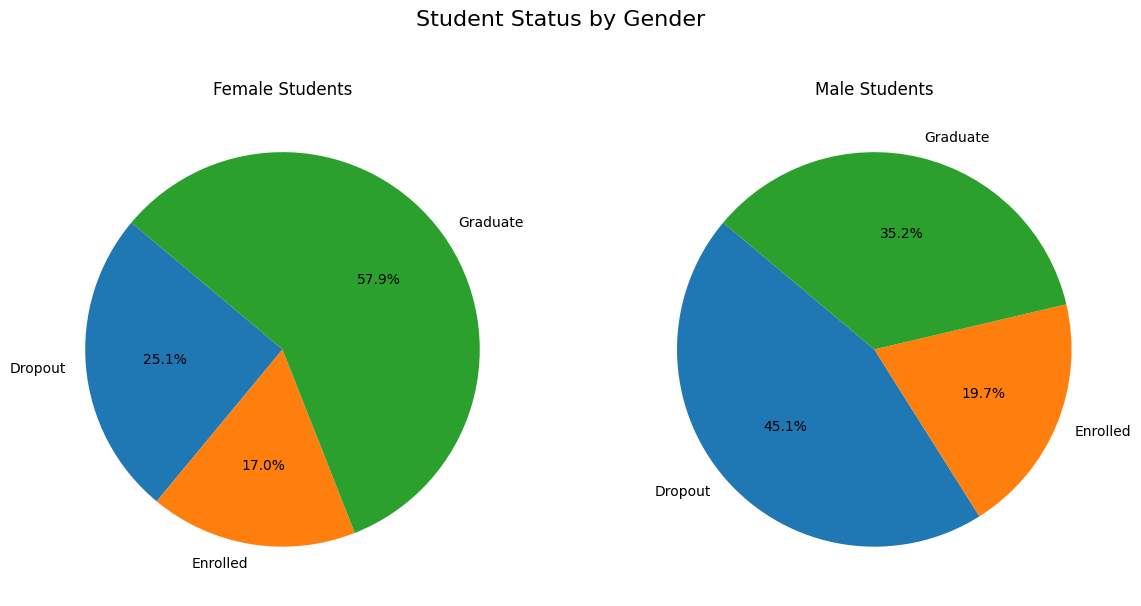

In [ ]:
#Phân tích tình hình bỏ học/ tốt nghiệp dựa trên giới tính sinh viên
gender_status_counts = df.groupby(['Gender', 'Target']).size().unstack(fill_value=0)
gender_status_percentages = gender_status_counts.div(gender_status_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Student Status by Gender', fontsize=16)

for i, (gender, status_percentages) in enumerate(gender_status_percentages.iterrows()):
    axes[i].pie(status_percentages, labels=status_percentages.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f'{gender.capitalize()} Students')

plt.show()

<ipython-input-14-cda591fd7c78>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dropout_df, x='Age group', palette='coolwarm')


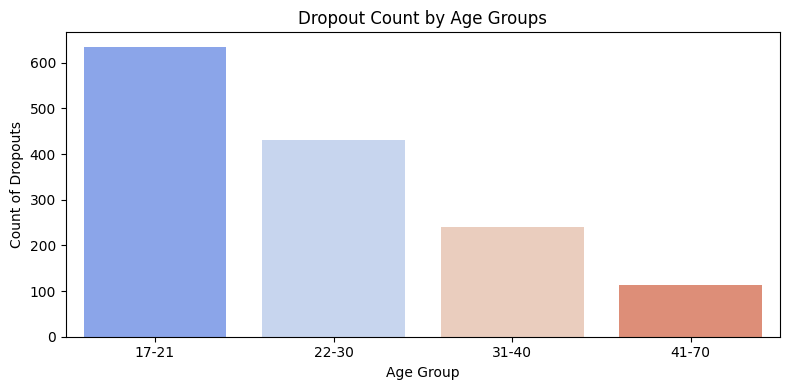

In [ ]:
#Độ tuổi nhập học của sinh viên

bins = [16, 21, 30, 40, 70]
labels = ['17-21', '22-30', '31-40', '41-70']

df['Age group'] = pd.cut(df['Age at enrollment'], bins=bins, labels=labels)

dropout_df = df[df['Target'] == 'Dropout']

plt.figure(figsize=(8, 4))
sns.countplot(data=dropout_df, x='Age group', palette='coolwarm')
plt.title('Dropout Count by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count of Dropouts')
plt.tight_layout()
plt.show()


<ipython-input-15-2f04335b9959>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, y='Nacionality', x='Dropout Rate', palette='coolwarm')


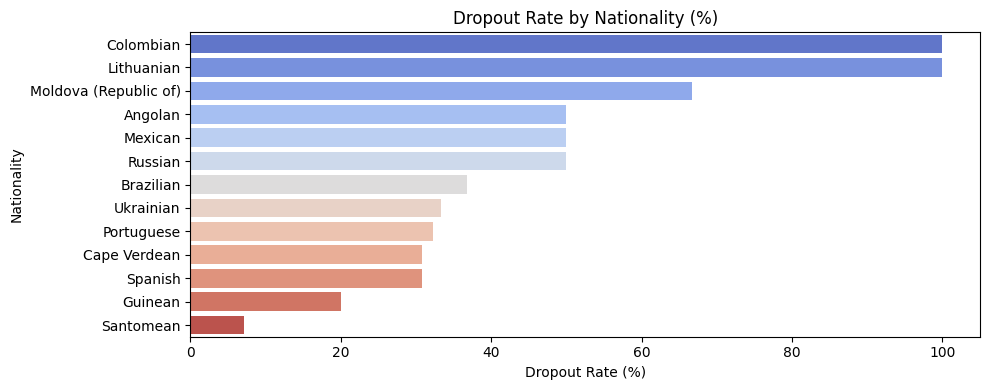

In [ ]:
#Tỷ lệ % bỏ học dựa trên quốc tịch sinh viên
# Tính tổng số sinh viên và số sinh viên bỏ học cho mỗi quốc tịch
nationality_counts = df['Nacionality'].value_counts().reset_index()
dropout_counts = df[df['Target'] == 'Dropout']['Nacionality'].value_counts().reset_index()

nationality_counts.columns = ['Nacionality', 'Total']
dropout_counts.columns = ['Nacionality', 'Dropout']

merged_df = pd.merge(nationality_counts, dropout_counts, on='Nacionality')

# Tính tỷ lệ bỏ học
merged_df['Dropout Rate'] = (merged_df['Dropout'] / merged_df['Total']) * 100
merged_df = merged_df.sort_values('Dropout Rate', ascending=False)

# vẽ biểu đồ
plt.figure(figsize=(10, 4))
sns.barplot(data=merged_df, y='Nacionality', x='Dropout Rate', palette='coolwarm')
plt.title('Dropout Rate by Nationality (%)')
plt.xlabel('Dropout Rate (%)')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

###4.1.2 Phân tích đặc điểm của cha mẹ

<ipython-input-16-1d12f7a2e116>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_merged_data, y='Marital Status', x='Dropout Rate', palette='coolwarm')


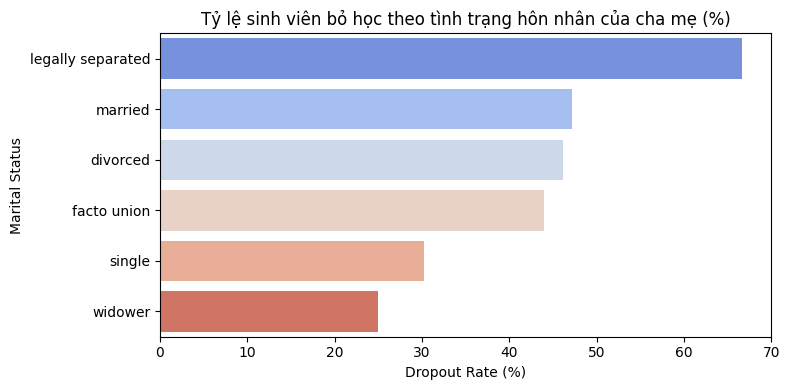

In [ ]:
#Tỷ lệ % bỏ học dựa trên tình trạng hôn nhân của cha mẹ
marital_status_counts = df['Marital status'].value_counts().reset_index()
dropout_counts_by_marital_status = df[df['Target'] == 'Dropout']['Marital status'].value_counts().reset_index()

marital_status_counts.columns = ['Marital Status', 'Total']
dropout_counts_by_marital_status.columns = ['Marital Status', 'Dropout']

merged_data = pd.merge(marital_status_counts, dropout_counts_by_marital_status, on='Marital Status')

# Tính tỷ lệ bỏ học
merged_data['Dropout Rate'] = (merged_data['Dropout'] / merged_data['Total']) * 100
sorted_merged_data = merged_data.sort_values('Dropout Rate', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=sorted_merged_data, y='Marital Status', x='Dropout Rate', palette='coolwarm')
plt.title('Tỷ lệ sinh viên bỏ học theo tình trạng hôn nhân của cha mẹ (%)')
plt.xlabel('Dropout Rate (%)')
plt.ylabel('Marital Status')
plt.tight_layout()
plt.show()

<ipython-input-17-7dcddb55e35e>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')


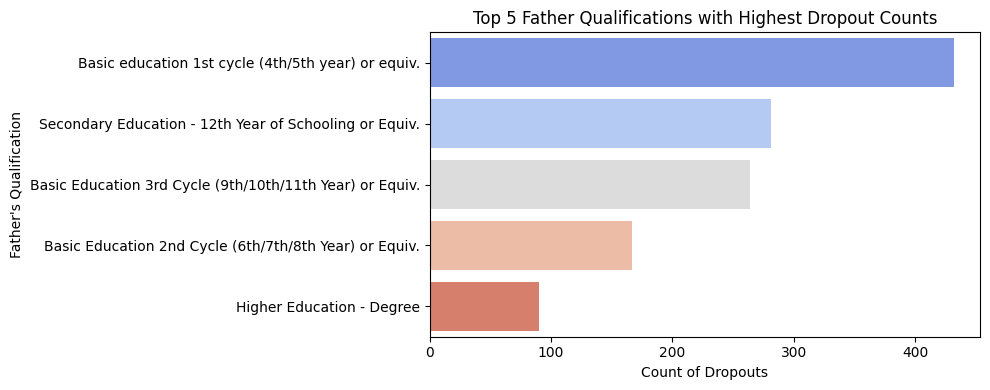

In [ ]:
#Học vấn của cha
dropout_df = df[df['Target'] == 'Dropout']

fathers_qualification_counts = dropout_df['Father\'s qualification'].value_counts()

top5_fathers_qualification = fathers_qualification_counts.head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')
plt.title('Top 5 Father Qualifications with Highest Dropout Counts')
plt.xlabel('Count of Dropouts')
plt.ylabel('Father\'s Qualification')
plt.tight_layout()
plt.show()

<ipython-input-18-d16c514cbf6f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')


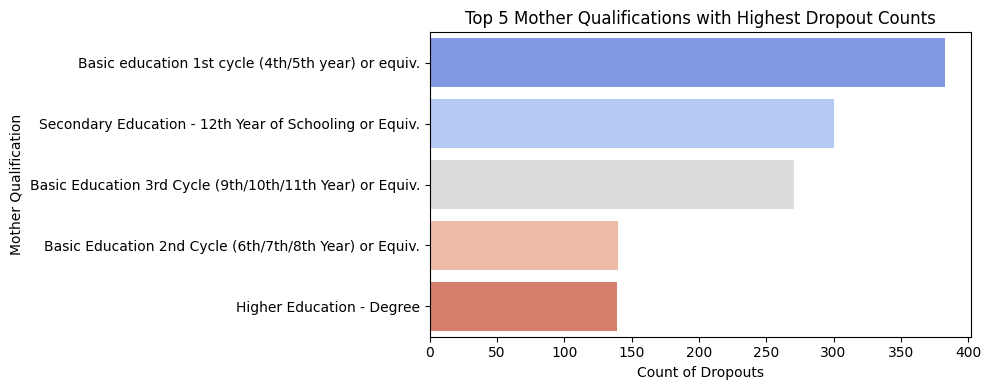

In [ ]:
#Học vấn của mẹ
dropout_df = df[df['Target'] == 'Dropout']

fathers_qualification_counts = dropout_df['Mother\'s qualification'].value_counts()

top5_fathers_qualification = fathers_qualification_counts.head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')
plt.title('Top 5 Mother Qualifications with Highest Dropout Counts')
plt.xlabel('Count of Dropouts')
plt.ylabel('Mother Qualification')
plt.tight_layout()
plt.show()

<ipython-input-19-529c7c7d89ea>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')


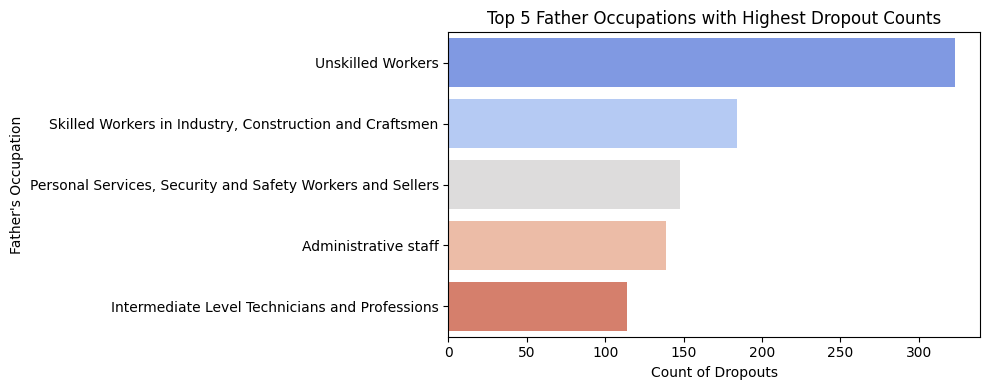

In [ ]:
#Nghề nghiệp cha
dropout_df = df[df['Target'] == 'Dropout']

fathers_qualification_counts = dropout_df['Father\'s occupation'].value_counts()

top5_fathers_qualification = fathers_qualification_counts.head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')
plt.title('Top 5 Father Occupations with Highest Dropout Counts')
plt.xlabel('Count of Dropouts')
plt.ylabel('Father\'s Occupation')
plt.tight_layout()
plt.show()

<ipython-input-20-a353a3179172>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')


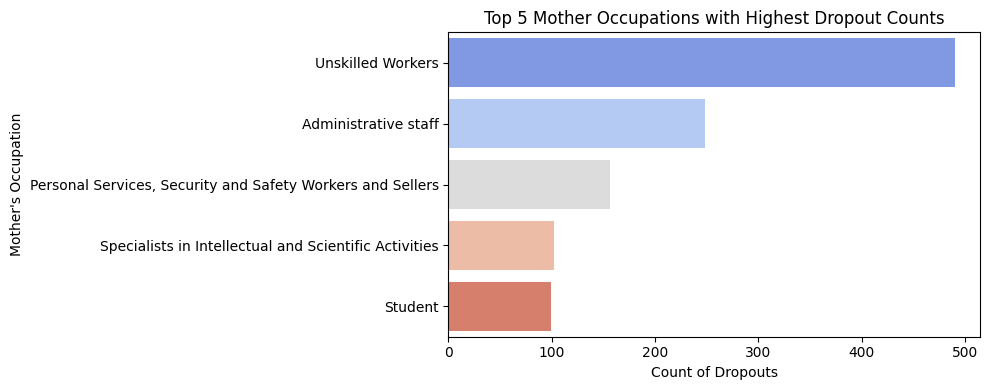

In [ ]:
#Nghề nghiệp mẹ
dropout_df = df[df['Target'] == 'Dropout']

fathers_qualification_counts = dropout_df['Mother\'s occupation'].value_counts()

top5_fathers_qualification = fathers_qualification_counts.head(5)

plt.figure(figsize=(10, 4))
sns.barplot(x=top5_fathers_qualification.values, y=top5_fathers_qualification.index, palette='coolwarm')
plt.title('Top 5 Mother Occupations with Highest Dropout Counts')
plt.xlabel('Count of Dropouts')
plt.ylabel('Mother\'s Occupation')
plt.tight_layout()
plt.show()

###4.1.3 Điểm nhập học và nguyện vọng đã đậu (Application order)

<ipython-input-21-6965e2284659>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_merged_app_order_data, y='Application Order', x='Dropout Rate', palette='viridis')


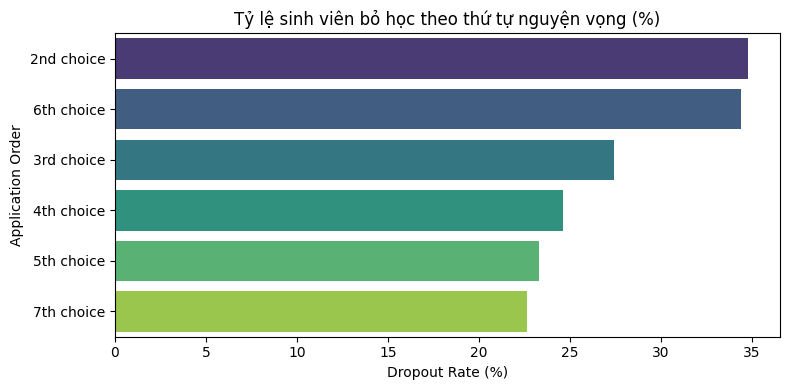

In [ ]:
# Tính tổng số sinh viên và số sinh viên bỏ học cho mỗi Application Order
app_order_counts = df['Application order'].value_counts().reset_index()
dropout_counts_by_app_order = df[df['Target'] == 'Dropout']['Application order'].value_counts().reset_index()
app_order_counts.columns = ['Application Order', 'Total']
dropout_counts_by_app_order.columns = ['Application Order', 'Dropout']

merged_app_order_data = pd.merge(app_order_counts, dropout_counts_by_app_order, on='Application Order')

# Tính tỷ lệ bỏ học
merged_app_order_data['Dropout Rate'] = (merged_app_order_data['Dropout'] / merged_app_order_data['Total']) * 100
sorted_merged_app_order_data = merged_app_order_data.sort_values('Dropout Rate', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=sorted_merged_app_order_data, y='Application Order', x='Dropout Rate', palette='viridis')
plt.title('Tỷ lệ sinh viên bỏ học theo thứ tự nguyện vọng (%)')
plt.xlabel('Dropout Rate (%)')
plt.ylabel('Application Order')
plt.tight_layout()
plt.show()

Tuy nhiên trong data còn 2 hạng mục của Application Order là 'first choice' và 'last choice' nhưng do không có sinh viên dropout nên chưa được thể hiện lên biểu đồ

-> có thể cân nhắc sử dụng biểu đồ bên dưới (đếm số lượng tuyệt đối sinh viên Dropout)

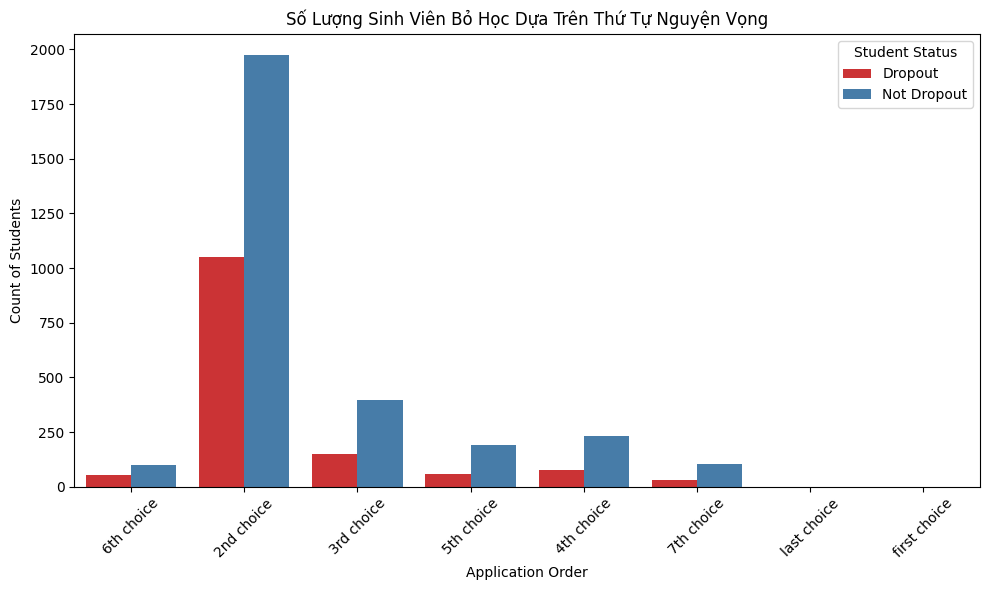

In [ ]:
# Tạo cột mới chỉ định nếu sinh viên là 'Dropout'
df['Is Dropout'] = df['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'Not Dropout')

# Vẽ Count Plot với hue='Is Dropout' để phân biệt giữa 'Dropout' và 'Not Dropout'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Application order', hue='Is Dropout', palette='Set1')
plt.title('Số Lượng Sinh Viên Bỏ Học Dựa Trên Thứ Tự Nguyện Vọng')
plt.xlabel('Application Order')
plt.ylabel('Count of Students')
plt.xticks(rotation=45)
plt.legend(title='Student Status')
plt.tight_layout()
plt.show()

<ipython-input-23-56cc1278c2ae>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dropout_data['Grade Group'] = pd.cut(dropout_data['Admission grade'], bins=bins, labels=labels, include_lowest=True)
<ipython-input-23-56cc1278c2ae>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dropout_data, x='Grade Group', palette='Spectral')


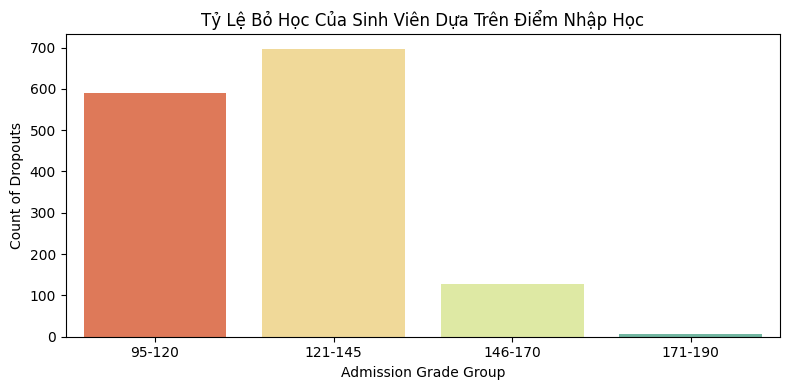

In [ ]:
#Tỷ lệ bỏ học dựa trên điểm nhập học
dropout_data = df[df['Target'] == 'Dropout']
bins = [95, 120, 145, 170, 190]
labels = ['95-120', '121-145', '146-170', '171-190']
dropout_data['Grade Group'] = pd.cut(dropout_data['Admission grade'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(8, 4))
sns.countplot(data=dropout_data, x='Grade Group', palette='Spectral')
plt.title('Tỷ Lệ Bỏ Học Của Sinh Viên Dựa Trên Điểm Nhập Học')
plt.xlabel('Admission Grade Group')
plt.ylabel('Count of Dropouts')
plt.tight_layout()
plt.show()


##4.2 Phân tích các yếu tố bên ngoài (External Factors)

###4.2.1 Ảnh hưởng của nguồn lực tài chính và học bổng

Text(0.5, 1.0, 'Debtor vs Dropout/Graduate')

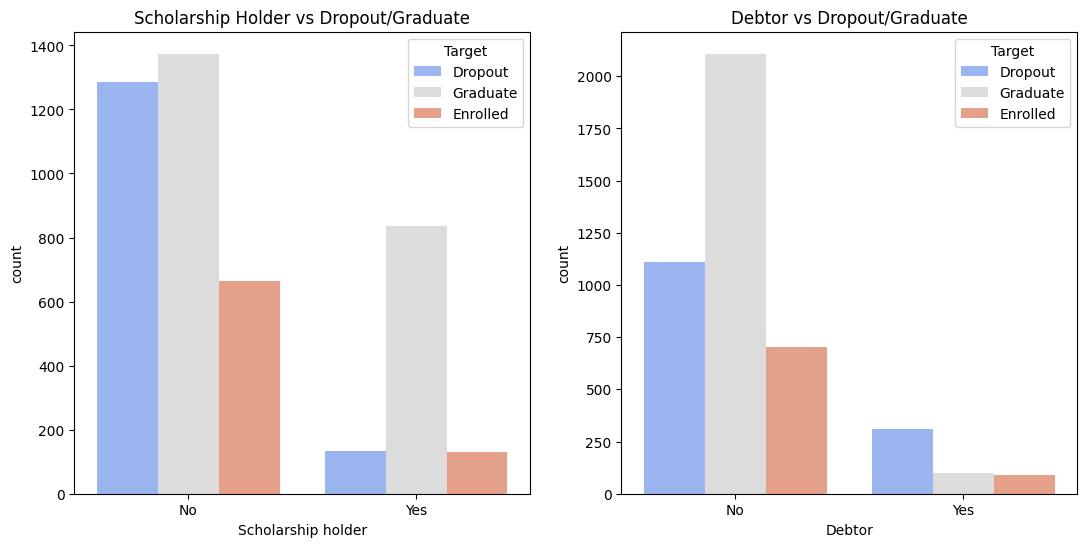

In [ ]:
# Biểu đồ thể hiện ảnh hưởng của nguồn lực tài chính đến tình trạng bỏ học
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Scholarship holder', hue='Target', palette='coolwarm')
plt.title('Scholarship Holder vs Dropout/Graduate')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Debtor', hue='Target', palette='coolwarm')
plt.title('Debtor vs Dropout/Graduate')

Biểu đồ 1: Về vấn đề học bổng

**+Trường hợp không được hỗ trợ học bổng:**

số lượng sinh viên bỏ học rất cao, chiếm tỷ lệ gần tương đương số học sinh tốt nghiệp và gấp đôi số học sinh đăng ký (đang theo học tại trường)

**+Trường hợp có học bổng:**

ngược lại với TH trên, số lượng sinh viên tốt nghiệp cao vượt trội, tỷ lệ bỏ học chỉ chiếm một tỷ lệ nhỏ tương đối.

**--> Insights:**
Có học bổng có vẻ là một yếu tố tích cực, có thể giúp giảm tỉ lệ bỏ học và tăng tỉ lệ tốt nghiệp hoặc tiếp tục theo học.

Biểu đồ 2: vấn đề sinh viên đang phải trả nợ

**+Không nợ nần:** Số lượng sinh viên đã tốt nghiệp cao hơn đáng kể so với những người bỏ học hoặc đang theo học.

**+Có nợ nần:** Số lượng sinh viên bỏ học tương đối cao, mặc dù không cao như số lượng sinh viên không nợ nần.

**Insights:**

Việc không có nợ nần có liên quan đến tỉ lệ tốt nghiệp cao, điều này có thể cho thấy gánh nặng tài chính là một yếu tố tiêu cực đối với việc hoàn thành học tập.

Các sinh viên có nợ nần có thể đối mặt với khó khăn tài chính, dẫn đến áp lực có thể ảnh hưởng đến việc học của họ và làm tăng khả năng bỏ học.

###4.2.2 Ngành học và hình thức học

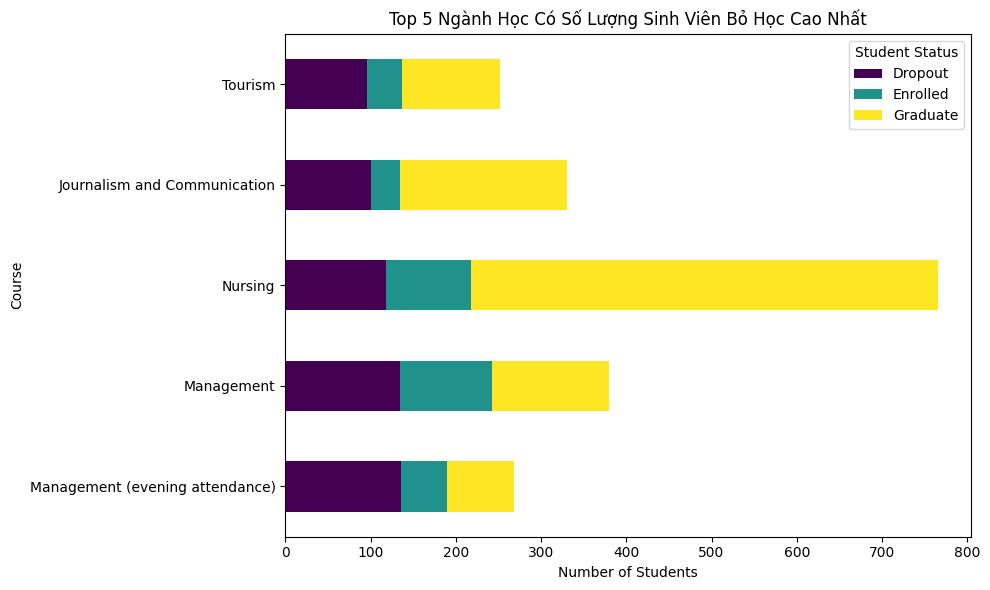

In [ ]:
course_status_counts = df.groupby(['Course', 'Target']).size().unstack(fill_value=0)

#Xác định top 5 khóa học có số lượng bỏ học cao nhất
top_5_dropout_courses = course_status_counts['Dropout'].nlargest(5).index
top_5_courses_data = course_status_counts.loc[top_5_dropout_courses]

top_5_courses_data.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Top 5 Ngành Học Có Số Lượng Sinh Viên Bỏ Học Cao Nhất')
plt.xlabel('Number of Students')
plt.ylabel('Course')
plt.legend(title='Student Status')
plt.tight_layout()
plt.show()

Đánh giá tổng quan:

**+Ngành điều dưỡng (Nursing):**

Số lượng sinh viên đã tốt nghiệp cao nhất trong số các ngành học được hiển thị. Tuy nhiên số sinh viên bỏ học cũng nằm ở mức tương đối

--> Điều này cho thấy ngành Điều Dưỡng có sức hút về mặt học thuật hoặc triển vọng nghề nghiệp sau tốt nghiệp, nhưng cũng có thể có áp lực hoặc thách thức dẫn đến tỉ lệ bỏ học đáng kể.

**+Ngành quản lý (chia ra 2 buổi):**

Cùng nằm trong top các ngành học có số lượng dropout cao, tuy nhiên tỷ lệ tốt nghiệp của các sinh viên đăng ký học ca tối thấp hơn hẳn.

**+Hai ngành học còn lại** có số lượng bỏ học và tốt nghiệp ở mức gần như tương đương nhau, phản ánh sự cạnh tranh cao trong ngành cũng như những thay đổi về nhu cầu thị trường lao động


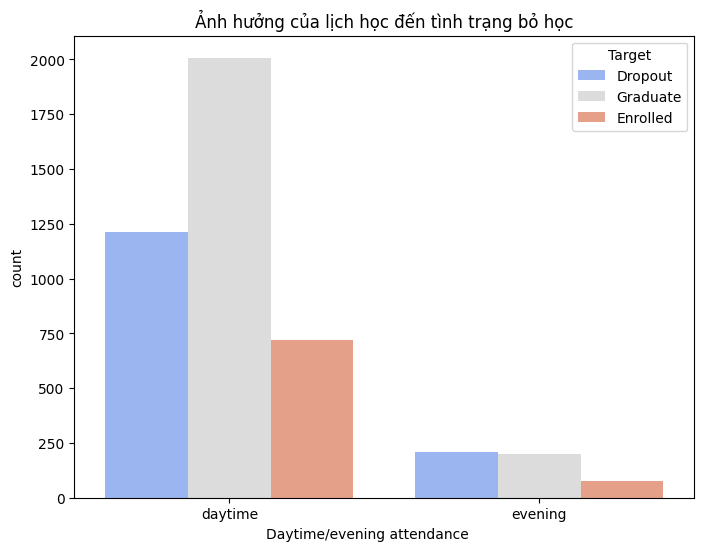

In [ ]:
#Ảnh hưởng của lịch học đến tình trạng bỏ học

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Daytime/evening attendance        ', hue='Target', palette='coolwarm') #chỗ tên cột bị dính khoảng trắng
plt.title('Ảnh hưởng của lịch học đến tình trạng bỏ học')
plt.show()

**Đánh Giá Chung:**

**Lịch Học Buổi Ngày:**
Là lựa chọn phổ biến với số lượng đông đảo sinh viên và có tỉ lệ tốt nghiệp cao hơn, có thể do sự tập trung và khả năng tiếp thu cao so với ban đêm.

**Lịch Học Buổi Tối:**
Dù phù hợp với những người có lịch trình bận rộn trong ngày, nhưng dường như không hỗ trợ tốt cho việc hoàn thành khóa học như lịch học buổi ngày nên ta có thể thấy tỷ lệ sinh viên bỏ học cao hơn hẳn so với tỷ lệ tốt nghiệp

**Đề xuất:**

Tìm hiểu kỹ hơn về những khó khăn mà sinh viên học buổi tối đối mặt và cung cấp thêm sự hỗ trợ.
Cải thiện sự linh hoạt và tài nguyên hỗ trợ cho học viên buổi tối.
Xem xét việc cung cấp tư vấn và lập kế hoạch nghề nghiệp để giúp sinh viên nhận thức được giá trị của việc hoàn thành khóa học.

In [ ]:
#Kiểm tra heading của mỗi columns
print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance        ', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International', 'Target', 'Age group',
       'Is Dropout'],
      dtype='object')


# **5. PREDICTED MODEL**

## 5.1 Mã hóa dữ liệu trong bảng

In [ ]:
selected_columns = df.select_dtypes(include=['object'])
#Mã hóa bằng LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in selected_columns.columns:
    df[column] = label_encoder.fit_transform(df[column])

In [ ]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Target
0,4,0,4,2,0,15,122.0,14,9,32,...,127.3,1,0,0,1,1,0,20,0,0
1,4,9,0,15,0,15,160.0,14,22,20,...,142.5,1,0,0,0,1,0,19,0,2
2,4,1,4,5,0,15,122.0,14,10,11,...,124.8,1,0,0,0,1,0,19,0,0
3,4,0,1,8,0,15,122.0,14,8,11,...,119.6,1,0,0,1,0,0,20,0,2
4,3,14,0,14,1,15,100.0,14,10,9,...,141.5,0,0,0,1,0,0,45,0,2


## 5.2 Mô hình dự đoán dựa trên toàn bộ dữ liệu

### 5.2.1 Chia dữ liệu

In [ ]:
y=df['Target']
X=df.drop('Target',axis='columns',inplace=False)
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

### 5.2.2 Xây dựng mô hình hồi quy với các thuật toán đã học:

1. LogisticrRegression
2. DecisionTreeClassifier
3. RandomForestClassifier
4. SVC
5. KNeighborsClassifie
6. Ensemble learning (Light GBM)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgb
import datetime
from sklearn import metrics
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV #RandomizedSearchCV

#### 5.2.2.1 Tối ưu hóa các hyperparameters

##### a. DecisionTreeClassifier

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

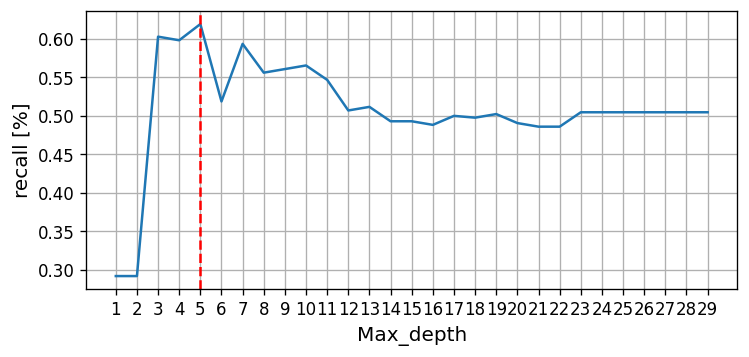

In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
from sklearn import tree
score_total=[]
for i in range(1,30):
  model_tree = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree.fit(X_train, y_train)
  y_pred=model_tree.predict(X_test)
  report = classification_report(y_test, y_pred, output_dict=True)
  score_total.append(report['0']['recall'])

#Vẽ hình thể hiện độ chính xác theo giá trị max_depth
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('recall [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 30), score_total)
plt.xticks(range(1, 30))
plt.axvline(x=5, color='r', linestyle='--')
plt.grid('minor')

##### b. Random Forest

In [ ]:
#hyperparameter turning
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier()
from sklearn.model_selection import GridSearchCV
grid_space = {'max_depth':[3, 5, 10, 20,25, None],
              'n_estimators':[2,5,9,10, 20, 30],
              'criterion':['gini','entropy']
              }
rf_grid = GridSearchCV(rf, param_grid=grid_space, scoring='accuracy')
model_grid = rf_grid.fit(X_train, y_train)

In [ ]:
model_grid.best_params_

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 30}

##### c. KNN

In [ ]:
from sklearn import metrics
ac=[] #Tạo list rỗng chứa giá trị của độ chính xác
for k in range (2,20,1):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  report = classification_report(y_test, y_pred, output_dict=True)
  ac.append(report['0']['recall'])
len(ac)

18

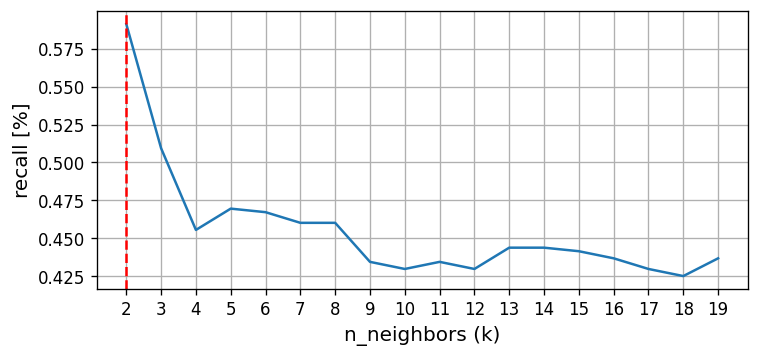

In [ ]:
#Vẽ hình thể hiện độ chính xác theo giá trị n_neighbors
plt.ylabel('recall [%]',fontsize=12)
plt.xlabel('n_neighbors (k)',fontsize=12)
plt.plot(range(2, 20), ac)
plt.xticks(range(2, 20))
plt.axvline(x=2, color='r', linestyle='--')
plt.grid('minor')

##### d. SVC

In [ ]:
#Tìm kiếm hyperparameter (C=[0.001, +], gamma=[>0,1])
hps={
    'C': [0.001, 0.01],
    'gamma' : [0.001, 0.01,0.1],
    'kernel' : ['linear']#, 'poly', 'rbf', 'sigmoid']
}
grids= GridSearchCV(SVC(),hps)
grids.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.001, 0.01], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['linear']})

In [ ]:
grids.best_params_

{'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}

##### e. Ensemble learning (Light GBM)

In [ ]:
#tìm kiếm siêu tham số tối ưu cho mô hình
Lig = lgb.LGBMClassifier()
hps={
    'num_leaves': [1, 10,100,1000],
     'learning_rate' : [0.00001, 0.0001, 0.001, 0.01, 1],
     'n_estimators' : [1, 10,100,1000],
}
grids= GridSearchCV(Lig, hps)
grids.fit(X_train, y_train)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1142, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 842, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 255, in train
    bo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 3096, number of used features: 21
[LightGBM] [Info] Start training from score -1.137136
[LightGBM] [Info] Start training from score -1.708145
[LightGBM] [Info] Start training from score -0.697031


GridSearchCV(estimator=LGBMClassifier(),
             param_grid={'learning_rate': [1e-05, 0.0001, 0.001, 0.01, 1],
                         'n_estimators': [1, 10, 100, 1000],
                         'num_leaves': [1, 10, 100, 1000]})

In [ ]:
t1e = datetime.datetime.now()
y_pred=grids.predict(X_test)
t2e= datetime.datetime.now()
d_e = round((t2e-t1e).microseconds/1000,1) #Tính thời gian

report_e = classification_report(y_test, y_pred, output_dict=True)

pre_Class_0_e = round(report_e['0']['precision'],2)
rec_Class_0_e = round(report_e['0']['recall'],2)
f1_Class_0_e = round(report_e['0']['f1-score'],2)

pre_Class_1_e = round(report_e['1']['precision'],2)
rec_Class_1_e = round(report_e['1']['recall'],2)
f1_Class_1_e = round(report_e['1']['f1-score'],2)

pre_Class_2_e = round(report_e['2']['precision'],2)
rec_Class_2_e = round(report_e['2']['recall'],2)
f1_Class_2_e = round(report_e['2']['f1-score'],2)

#### 5.2.2.2 Tổng hợp các mô hình

In [ ]:
#Tạo danh sách chứa tên mô hình:
models = [LogisticRegression(),
    DecisionTreeClassifier(max_depth=5,random_state=1),
    RandomForestClassifier(n_estimators=20, max_depth=5, criterion='entropy',random_state=1),
    SVC(kernel='linear', C= 0.01, gamma=0.001),
    KNeighborsClassifier(n_neighbors=2)]

In [ ]:
precision_Class_0=[]
recall_Class_0=[]
f1score_Class_0=[]
precision_Class_1=[]
recall_Class_1=[]
f1score_Class_1=[]
precision_Class_2=[]
recall_Class_2=[]
f1score_Class_2=[]
time=[]
name=[]

In [ ]:
for model in models:
  t1 = datetime.datetime.now()
  model_name = model.__class__.__name__
  model.fit(X_train, y_train)
  t2= datetime.datetime.now()
  d = round((t2-t1).microseconds/1000,1) #Tính thời gian
  y_pred = model.predict(X_test)
  report = classification_report(y_test, y_pred, output_dict=True)
  pre_Class_0 = round(report['0']['precision'],2)
  rec_Class_0 = round(report['0']['recall'],2)
  f1_Class_0= round(report['0']['f1-score'],2)

  pre_Class_1 = round(report['1']['precision'],2)
  rec_Class_1 = round(report['1']['recall'],2)
  f1_Class_1 = round(report['1']['f1-score'],2)

  pre_Class_2 = round(report['2']['precision'],2)
  rec_Class_2 = round(report['2']['recall'],2)
  f1_Class_2 = round(report['2']['f1-score'],2)

  precision_Class_0.append(pre_Class_0)
  recall_Class_0.append(rec_Class_0)
  f1score_Class_0.append(f1_Class_0)
  precision_Class_1.append(pre_Class_1)
  recall_Class_1.append(rec_Class_1)
  f1score_Class_1.append(f1_Class_1)
  precision_Class_2.append(pre_Class_2)
  recall_Class_2.append(rec_Class_2)
  f1score_Class_2.append(f1_Class_2)
  time.append(d)
  name.append(model_name)

precision_Class_0.append(pre_Class_0_e)
recall_Class_0.append(rec_Class_0_e)
f1score_Class_0.append(f1_Class_0_e)
precision_Class_1.append(pre_Class_1_e)
recall_Class_1.append(rec_Class_1_e)
f1score_Class_1.append(f1_Class_1_e)
precision_Class_2.append(pre_Class_2_e)
recall_Class_2.append(rec_Class_2_e)
f1score_Class_2.append(f1_Class_2_e)
time.append(d_e)
name.append('Ensemble learning')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels wit

### 5.2.3 Đưa kết quả thành một bảng tổng hợp.


In [ ]:
#Đưa kết quả thành một bảng tổng hợp.
import numpy as np
Results = pd.DataFrame(np.column_stack([name, precision_Class_0, recall_Class_0,f1score_Class_0,
                                        precision_Class_1,recall_Class_1,f1score_Class_1,precision_Class_2,recall_Class_2,f1score_Class_2,time]),
                       columns=['Name', 'Precision_Class_0','Recall_Class_0','F1-score_Class_0',
                                'Precision_Class_1','Recall_Class_1','F1-score_Class_1','Precision_Class_2','Recall_Class_2','F1-score_Class_2','Time (s)'])
Results

,Name,Precision_Class_0,Recall_Class_0,F1-score_Class_0,Precision_Class_1,Recall_Class_1,F1-score_Class_1,Precision_Class_2,Recall_Class_2,F1-score_Class_2,Time (s)
0,LogisticRegression,0.65,0.48,0.55,0.0,0.0,0.0,0.59,0.9,0.72,104.6
1,DecisionTreeClassifier,0.6,0.62,0.61,0.2,0.0,0.01,0.63,0.83,0.72,9.1
2,RandomForestClassifier,0.67,0.56,0.61,0.0,0.0,0.0,0.61,0.89,0.73,55.2
3,SVC,0.72,0.46,0.56,0.0,0.0,0.0,0.59,0.93,0.72,781.7
4,KNeighborsClassifier,0.4,0.59,0.48,0.2,0.27,0.23,0.58,0.34,0.43,3.0
5,Ensemble learning,0.67,0.56,0.61,0.29,0.12,0.17,0.66,0.87,0.75,267.8


## 5.3 Mô hình dự đoán dựa trên data đã được xử lý (xử lý mất cân bằng/ lựa chọn biến)

####5.3.1 Chia dữ liệu

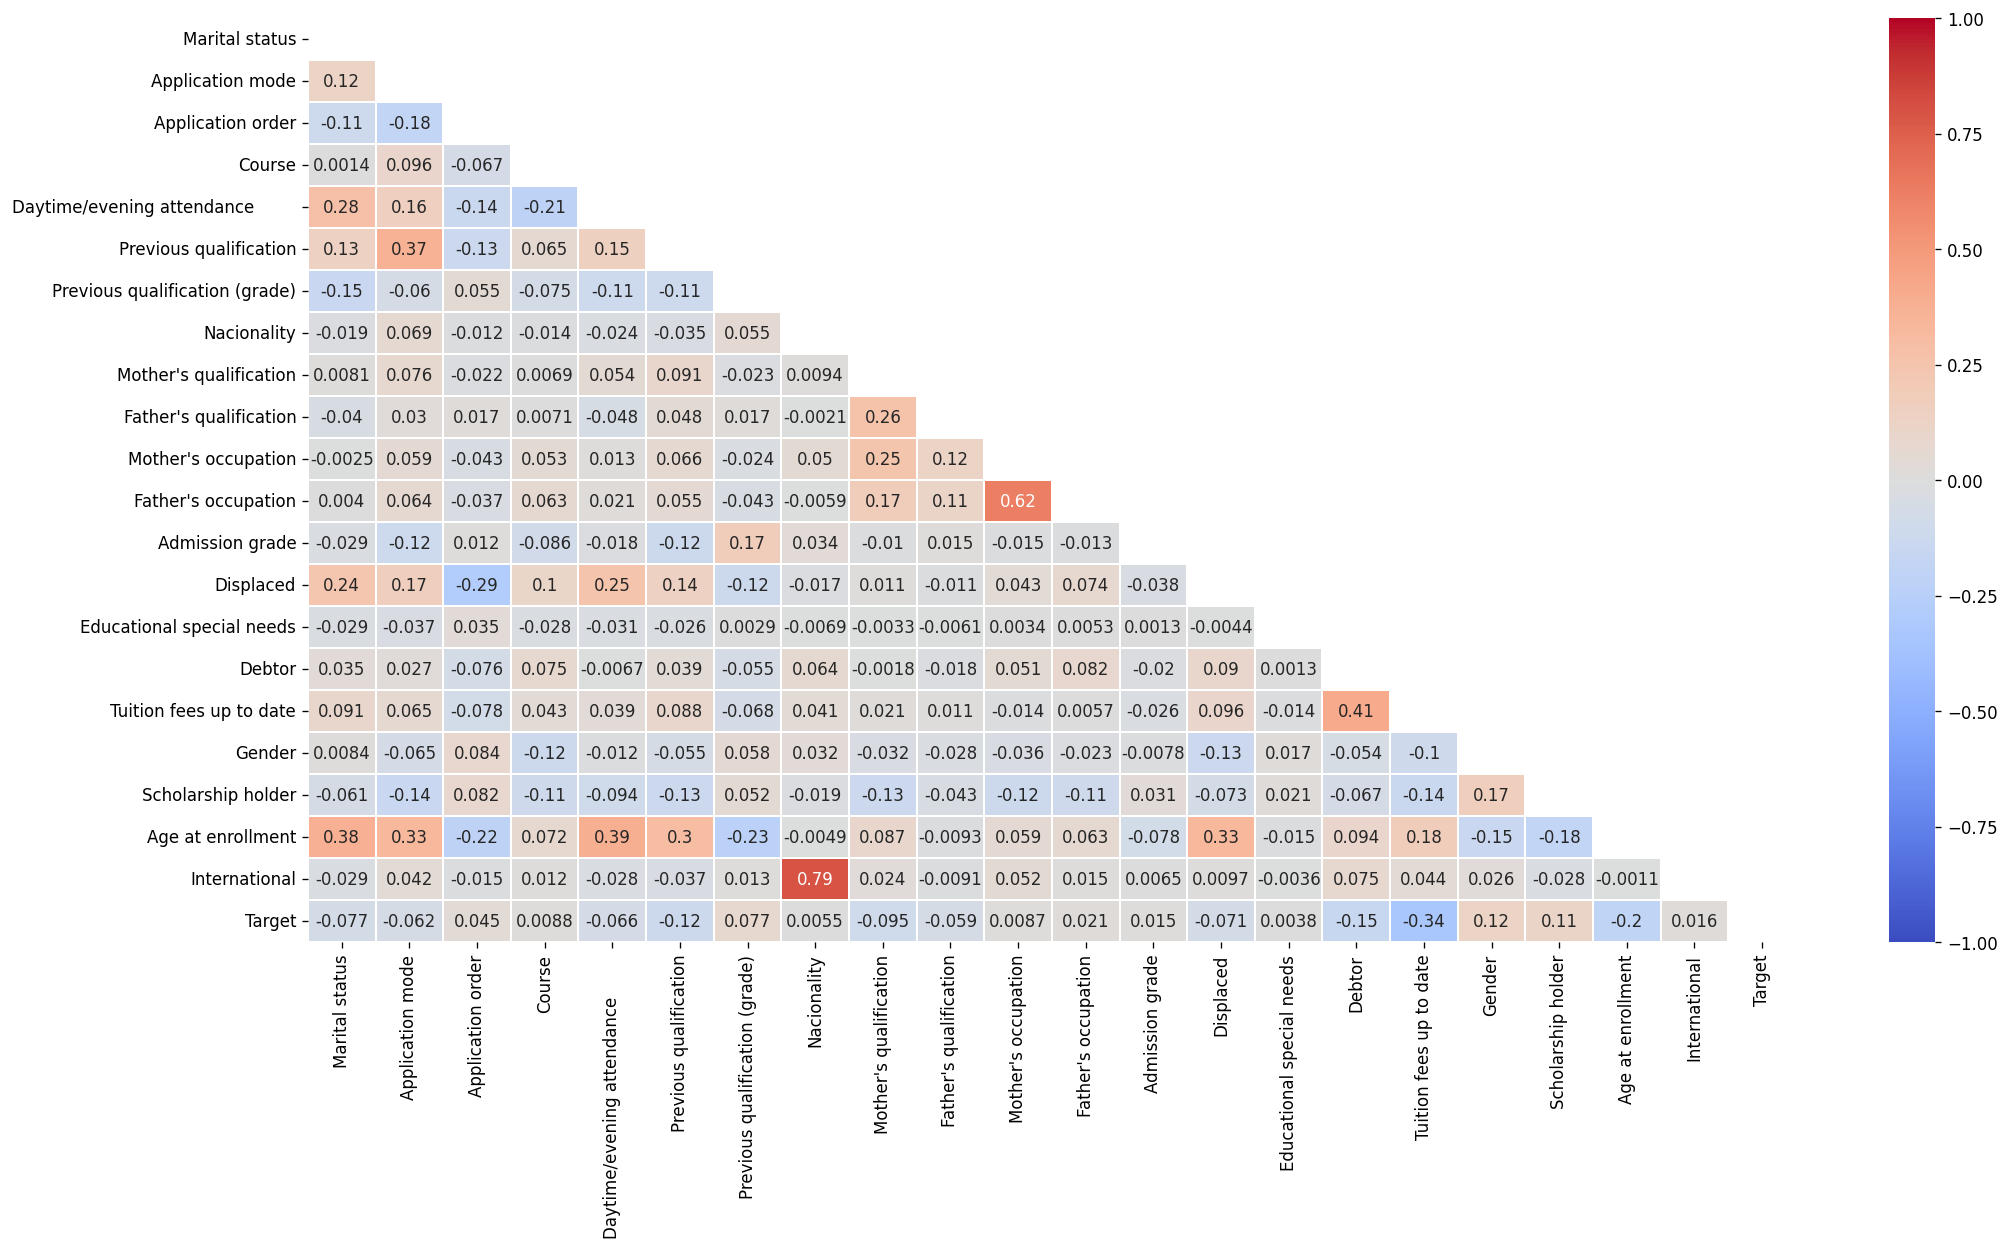

In [ ]:
#CORR
import numpy as np
plt.rcParams.update({'figure.figsize':(20,10), 'figure.dpi':120})
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

Nhận xét: Theo biểu đồ heatmap, Target phụ thuộc chủ yếu vào các features:

* Application order
* Course
* Previous qualification (grade)
* Nacionality
* Mother's occupation
* Father's occupation
* Admission grade
* Educational special needs
* Gender
* Scholarship holder
* International



In [ ]:
y=df['Target']
X=df[["Application order", "Course", "Previous qualification (grade)", "Nacionality", "Mother's occupation",
      "Father's occupation","Admission grade", "Educational special needs", "Gender", "Scholarship holder", "International" ]]
#Chia dữ liệu thành training set và test set

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

#### 5.3.2 Kiểm tra/xử lý mất cân bằng dữ liệu của X_train, y_train

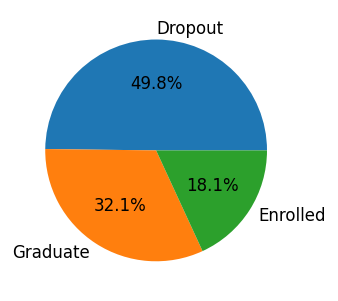

In [ ]:
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.pie(y_train.value_counts(), autopct='%1.1f%%', labels=['Dropout', 'Graduate', 'Enrolled'])
plt.show()

**Nhận xét:**  Dữ liệu y_train đang mất cân bằng giữa 3 nhóm dữ liệu. Cần xử lý để tăng tính chính xác cho mô hình

In [ ]:
# Xử lý mất cân bằng với SMOTE
from imblearn.over_sampling import SMOTE
Oversample = SMOTE()
X_train, y_train = Oversample.fit_resample(X_train, y_train)

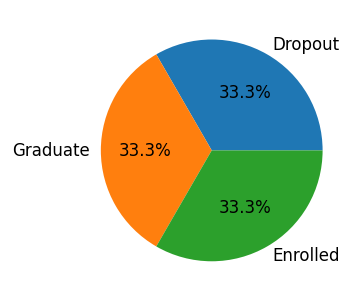

In [ ]:
#Kiểm tra lại dữ liệu sau khi xử lý mất cân bằng
plt.pie(y_train.value_counts(), autopct='%1.1f%%', labels=['Dropout', 'Graduate', 'Enrolled'])
plt.show()

### 5.3.3 Xây dựng mô hình hồi quy với các thuật toán đã học:

1. LogisticrRegression
2. DecisionTreeClassifier
3. RandomForestClassifier
4. SVC
5. KNeighborsClassifie
6. Ensemble learning (Light GBM)

#### 5.3.3.1 Tối ưu hóa các hyperparameters

##### a. DecisionTreeClassifier

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

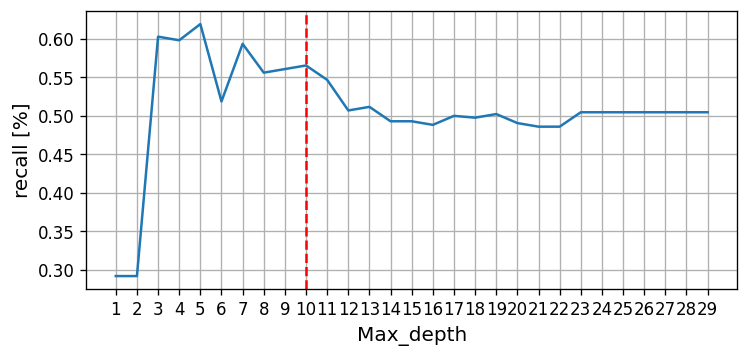

In [ ]:
# Sử dụng vòng lặp for để tìm max_depth
from sklearn import tree
score_total=[]
for i in range(1,30):
  model_tree = tree.DecisionTreeClassifier(max_depth=i,random_state=1)
  model_tree.fit(X_train, y_train)
  y_pred=model_tree.predict(X_test)
  report = classification_report(y_test, y_pred, output_dict=True)
  score_total.append(report['0']['recall'])

#Vẽ hình thể hiện độ chính xác theo giá trị max_depth
plt.rcParams.update({'figure.figsize':(7,3), 'figure.dpi':120})
plt.ylabel('recall [%]',fontsize=12)
plt.xlabel('Max_depth',fontsize=12)
plt.plot(range(1, 30), score_total)
plt.xticks(range(1, 30))
plt.axvline(x=10, color='r', linestyle='--')
plt.grid('minor')

##### b. Random Forest

In [ ]:
#hyperparameter turning
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier()
from sklearn.model_selection import GridSearchCV
grid_space = {'max_depth':[3, 5, 10, 20,25, None],
              'n_estimators':[2,5,9,10, 20, 30],
              'criterion':['gini','entropy']
              }
rf_grid = GridSearchCV(rf, param_grid=grid_space, scoring='accuracy')
model_grid = rf_grid.fit(X_train, y_train)

In [ ]:
model_grid.best_params_

{'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 30}

##### c. KNN

In [ ]:
from sklearn import metrics
ac=[] #Tạo list rỗng chứa giá trị của độ chính xác
for k in range (2,20,1):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  report = classification_report(y_test, y_pred, output_dict=True)
  ac.append(report['0']['recall'])
len(ac)

18

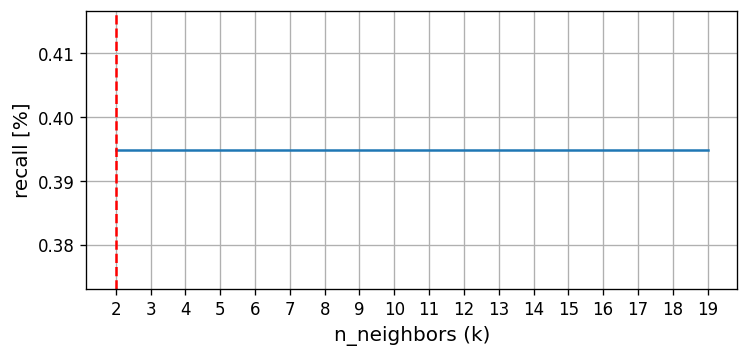

In [ ]:
#Vẽ hình thể hiện độ chính xác theo giá trị n_neighbors
plt.ylabel('recall [%]',fontsize=12)
plt.xlabel('n_neighbors (k)',fontsize=12)
plt.plot(range(2, 20), ac)
plt.xticks(range(2, 20))
plt.axvline(x=2, color='r', linestyle='--')
plt.grid('minor')

##### d. SVC

In [ ]:
#Tìm kiếm hyperparameter (C=[0.001, +], gamma=[>0,1])
hps={
    'C': [0.001, 0.01],
    'gamma' : [0.001, 0.01,0.1],
    'kernel' : ['linear']#, 'poly', 'rbf', 'sigmoid']
}
grids= GridSearchCV(SVC(),hps)
grids.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.001, 0.01], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['linear']})

In [ ]:
grids.best_params_

{'C': 0.01, 'gamma': 0.001, 'kernel': 'linear'}

##### e. Ensemble learning (Light GBM)

In [ ]:
#tìm kiếm siêu tham số tối ưu cho mô hình
Lig = lgb.LGBMClassifier()
hps={
    'num_leaves': [1, 10,100,1000],
     'learning_rate' : [0.00001, 0.0001, 0.001, 0.01, 1],
     'n_estimators' : [1, 10,100,1000],
}
grids= GridSearchCV(Lig, hps)
grids.fit(X_train, y_train)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1142, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 842, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 255, in train
    bo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 4626, number of used features: 11
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

GridSearchCV(estimator=LGBMClassifier(),
             param_grid={'learning_rate': [1e-05, 0.0001, 0.001, 0.01, 1],
                         'n_estimators': [1, 10, 100, 1000],
                         'num_leaves': [1, 10, 100, 1000]})

In [ ]:
t1e = datetime.datetime.now()
y_pred=grids.predict(X_test)
t2e= datetime.datetime.now()
d_e = round((t2e-t1e).microseconds/1000,1) #Tính thời gian

report_e = classification_report(y_test, y_pred, output_dict=True)

pre_Class_0_e = round(report_e['0']['precision'],2)
rec_Class_0_e = round(report_e['0']['recall'],2)
f1_Class_0_e = round(report_e['0']['f1-score'],2)

pre_Class_1_e = round(report_e['1']['precision'],2)
rec_Class_1_e = round(report_e['1']['recall'],2)
f1_Class_1_e = round(report_e['1']['f1-score'],2)

pre_Class_2_e = round(report_e['2']['precision'],2)
rec_Class_2_e = round(report_e['2']['recall'],2)
f1_Class_2_e = round(report_e['2']['f1-score'],2)

#### 5.3.3.2 Tổng hợp các mô hình

In [ ]:
#Tạo danh sách chứa tên mô hình:
models = [LogisticRegression(),
    DecisionTreeClassifier(max_depth=5,random_state=1),
    RandomForestClassifier(n_estimators=20, max_depth=20, criterion='entropy',random_state=1),
    SVC(kernel='linear', C= 0.01, gamma=0.001),
    KNeighborsClassifier(n_neighbors=2)]

In [ ]:
precision_Class_0=[]
recall_Class_0=[]
f1score_Class_0=[]
precision_Class_1=[]
recall_Class_1=[]
f1score_Class_1=[]
precision_Class_2=[]
recall_Class_2=[]
f1score_Class_2=[]
time=[]
name=[]

In [ ]:
for model in models:
  t1 = datetime.datetime.now()
  model_name = model.__class__.__name__
  model.fit(X_train, y_train)
  t2= datetime.datetime.now()
  d = round((t2-t1).microseconds/1000,1) #Tính thời gian
  y_pred = model.predict(X_test)
  report = classification_report(y_test, y_pred, output_dict=True)
  pre_Class_0 = round(report['0']['precision'],2)
  rec_Class_0 = round(report['0']['recall'],2)
  f1_Class_0= round(report['0']['f1-score'],2)

  pre_Class_1 = round(report['1']['precision'],2)
  rec_Class_1 = round(report['1']['recall'],2)
  f1_Class_1 = round(report['1']['f1-score'],2)

  pre_Class_2 = round(report['2']['precision'],2)
  rec_Class_2 = round(report['2']['recall'],2)
  f1_Class_2 = round(report['2']['f1-score'],2)

  precision_Class_0.append(pre_Class_0)
  recall_Class_0.append(rec_Class_0)
  f1score_Class_0.append(f1_Class_0)
  precision_Class_1.append(pre_Class_1)
  recall_Class_1.append(rec_Class_1)
  f1score_Class_1.append(f1_Class_1)
  precision_Class_2.append(pre_Class_2)
  recall_Class_2.append(rec_Class_2)
  f1score_Class_2.append(f1_Class_2)
  time.append(d)
  name.append(model_name)

precision_Class_0.append(pre_Class_0_e)
recall_Class_0.append(rec_Class_0_e)
f1score_Class_0.append(f1_Class_0_e)
precision_Class_1.append(pre_Class_1_e)
recall_Class_1.append(rec_Class_1_e)
f1score_Class_1.append(f1_Class_1_e)
precision_Class_2.append(pre_Class_2_e)
recall_Class_2.append(rec_Class_2_e)
f1score_Class_2.append(f1_Class_2_e)
time.append(d_e)
name.append('Ensemble learning')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5.3.4 Đưa kết quả thành một bảng tổng hợp.

In [ ]:
#Đưa kết quả thành một bảng tổng hợp.
import numpy as np
Results_1 = pd.DataFrame(np.column_stack([name, precision_Class_0, recall_Class_0,f1score_Class_0,
                                        precision_Class_1,recall_Class_1,f1score_Class_1,precision_Class_2,recall_Class_2,f1score_Class_2,time]),
                       columns=['Name', 'Precision_Class_0','Recall_Class_0','F1-score_Class_0',
                                'Precision_Class_1','Recall_Class_1','F1-score_Class_1','Precision_Class_2','Recall_Class_2','F1-score_Class_2','Time (s)'])
Results_1

,Name,Precision_Class_0,Recall_Class_0,F1-score_Class_0,Precision_Class_1,Recall_Class_1,F1-score_Class_1,Precision_Class_2,Recall_Class_2,F1-score_Class_2,Time (s)
0,LogisticRegression,0.47,0.44,0.46,0.17,0.28,0.21,0.67,0.55,0.6,89.1
1,DecisionTreeClassifier,0.51,0.44,0.47,0.19,0.24,0.21,0.67,0.66,0.66,9.6
2,RandomForestClassifier,0.5,0.54,0.52,0.21,0.24,0.22,0.67,0.61,0.64,174.9
3,SVC,0.44,0.51,0.47,0.19,0.37,0.25,0.76,0.43,0.55,173.1
4,KNeighborsClassifier,0.37,0.57,0.44,0.2,0.3,0.24,0.58,0.27,0.37,7.7
5,Ensemble learning,0.48,0.49,0.49,0.24,0.24,0.24,0.65,0.64,0.64,396.8


# **6. TỔNG KẾT**

## 6.1 Nguyên nhân dẫn đến tình trạng bỏ học

## 6.2 Lựa chọn mô hình dự đoán

In [ ]:
# Dữ liệu data chưa xử lý
Results

,Name,Precision_Class_0,Recall_Class_0,F1-score_Class_0,Precision_Class_1,Recall_Class_1,F1-score_Class_1,Precision_Class_2,Recall_Class_2,F1-score_Class_2,Time (s)
0,LogisticRegression,0.65,0.48,0.55,0.0,0.0,0.0,0.59,0.9,0.72,104.6
1,DecisionTreeClassifier,0.6,0.62,0.61,0.2,0.0,0.01,0.63,0.83,0.72,9.1
2,RandomForestClassifier,0.67,0.56,0.61,0.0,0.0,0.0,0.61,0.89,0.73,55.2
3,SVC,0.72,0.46,0.56,0.0,0.0,0.0,0.59,0.93,0.72,781.7
4,KNeighborsClassifier,0.4,0.59,0.48,0.2,0.27,0.23,0.58,0.34,0.43,3.0
5,Ensemble learning,0.67,0.56,0.61,0.29,0.12,0.17,0.66,0.87,0.75,267.8


In [ ]:
# Dữ liệu đã chọn lại biến X và xử lý mất cân bằng dữ liệu
Results_1

,Name,Precision_Class_0,Recall_Class_0,F1-score_Class_0,Precision_Class_1,Recall_Class_1,F1-score_Class_1,Precision_Class_2,Recall_Class_2,F1-score_Class_2,Time (s)
0,LogisticRegression,0.47,0.44,0.46,0.17,0.28,0.21,0.67,0.55,0.6,89.1
1,DecisionTreeClassifier,0.51,0.44,0.47,0.19,0.24,0.21,0.67,0.66,0.66,9.6
2,RandomForestClassifier,0.5,0.54,0.52,0.21,0.24,0.22,0.67,0.61,0.64,174.9
3,SVC,0.44,0.51,0.47,0.19,0.37,0.25,0.76,0.43,0.55,173.1
4,KNeighborsClassifier,0.37,0.57,0.44,0.2,0.3,0.24,0.58,0.27,0.37,7.7
5,Ensemble learning,0.48,0.49,0.49,0.24,0.24,0.24,0.65,0.64,0.64,396.8


Dựa vào so sánh trên, mô hình tối ưu nhất dùng để dự đoán khả năng học sinh, sinh viên bỏ học là mô hình Ensemble Learning (Light GBM) với dữ liệu ban đầu.

In [ ]:
y=df['Target']
X=df.drop('Target',axis='columns',inplace=False)
#Chia dữ liệu thành training set và test set
from sklearn.model_selection import train_test_split # Thư viện hỗ trợ chia data thành train và test set
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [ ]:
#tìm kiếm siêu tham số tối ưu cho mô hình
Lig = lgb.LGBMClassifier()
hps={
    'num_leaves': [1, 10,100,1000],
     'learning_rate' : [0.00001, 0.0001, 0.001, 0.01, 1],
     'n_estimators' : [1, 10,100,1000],
}
grids= GridSearchCV(Lig, hps)
grids.fit(X_train, y_train)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1142, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 842, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 255, in train
    bo

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 3096, number of used features: 21
[LightGBM] [Info] Start training from score -1.137136
[LightGBM] [Info] Start training from score -1.708145
[LightGBM] [Info] Start training from score -0.697031


GridSearchCV(estimator=LGBMClassifier(),
             param_grid={'learning_rate': [1e-05, 0.0001, 0.001, 0.01, 1],
                         'n_estimators': [1, 10, 100, 1000],
                         'num_leaves': [1, 10, 100, 1000]})

In [ ]:
y_pred=grids.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
target_names = ['Dropout', 'Enrolled', 'Graduate'] # 0 = Dropout, 1 = Enrolled , 2 = Graduate
print(classification_report(y_test, y_pred,target_names = target_names))

              precision    recall  f1-score   support

     Dropout       0.67      0.56      0.61       428
    Enrolled       0.29      0.12      0.17       233
    Graduate       0.66      0.87      0.75       667

    accuracy                           0.63      1328
   macro avg       0.54      0.51      0.51      1328
weighted avg       0.60      0.63      0.60      1328

